# Una mina tala una hectárea de bosque. A su alrededor desaparecen 34 más.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

El cobalto de tu teléfono y el cobre de un carro eléctrico salen, en buena parte, de minas africanas abiertas entre selva densa. Un equipo rastreó **16.627 minas** en toda el África subsahariana con imágenes de satélite y se hizo una pregunta incómoda: ¿cuánto bosque se pierde *de más* solo por tener una mina al lado?

**Paper:** Morton et al. (2026), *Mining triggers extensive additional deforestation in sub-Saharan Africa*, **Nature**.  
**DOI:** [10.1038/s41586-026-10551-2](https://doi.org/10.1038/s41586-026-10551-2)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-03-mineria-deforestacion-africa/notebook.ipynb)

*Video del canal: [Ver en YouTube](https://youtube.com/shorts/Jn_slU06Orc)*

## Qué midieron

Cada mina deja una huella **directa**: el pozo, las balsas de relaves, los montones de escombros. Pero alrededor llega gente, caminos, cultivos y pueblos — y el bosque también cae ahí. El equipo midió la pérdida forestal en anillos a **1, 5, 10 y 20 km** de cada mina, entre 2001 y 2020, sobre bosque denso (≥50% de cobertura).

Para separar lo que causa la mina de lo que habría pasado igual, usaron un marco de **diferencias-en-diferencias** (comparar la zona minada contra zonas parecidas todavía sin mina). Nosotros aquí reproducimos la versión **cruda** con los datos públicos: alineamos cada mina al año en que abrió y miramos cómo se mueve la curva.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
HEADLINE_PAPER_PP = 8.0       # deforestación adicional a 1 km que estima el paper (IC 7.2-8.9)
RATIO_OFFSITE = 34            # ha perdidas alrededor por cada 1 ha de tala directa (5 años)
HA_DIRECTA = 187070          # ha de tala directa total (huella de las minas)
FUENTE = 'Fuente: Morton et al. (2026), Nature | Datos: OMorton/AFR_MiningForestLoss (GitHub)'
COLOR_CERCA = '#DC2626'       # 1 km — el anillo de alerta
COLOR_MEDIO = '#D97706'       # 5 km
COLOR_LEJOS = '#059669'       # 10 km
COLOR_FONDO = '#BBBBBB'       # 20 km — casi el fondo regional
COLOR_DATOS = '#2563EB'

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Estilo CaM (local -> /tmp -> GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Carga
ev = pd.read_csv('datos/evento_estudio_distancia.csv')      # event-study por anillo
dd = pd.read_csv('datos/deforestacion_adicional.csv')       # doble-diferencia vs fondo 20km
co = pd.read_csv('datos/comodidades_deforestacion.csv')     # por mineral

print(f'Event-study: {len(ev)} filas, anillos = {sorted(ev.buffer.unique())}')
print(f'Años relativos: {int(ev.rel_year.min())} a {int(ev.rel_year.max())} '
      f'(0 = año en que abre la mina)')
print(f'Minas (clusters) en t=-1, anillo 1km: '
      f"{int(ev[(ev.buffer=='1km') & (ev.rel_year==-1)].n_obs.iloc[0]):,}")
print(f'Minerales con dato: {list(co.commodity)}')

Event-study: 64 filas, anillos = ['10km', '1km', '20km', '5km']
Años relativos: -5 a 10 (0 = año en que abre la mina)
Minas (clusters) en t=-1, anillo 1km: 15,255
Minerales con dato: ['Uranio', 'Cobalto', 'Cobre', 'Diamante', 'Oro', 'Plata', 'Manganeso']


Alineamos las 16.627 minas al año en que abrieron. Aquí está.

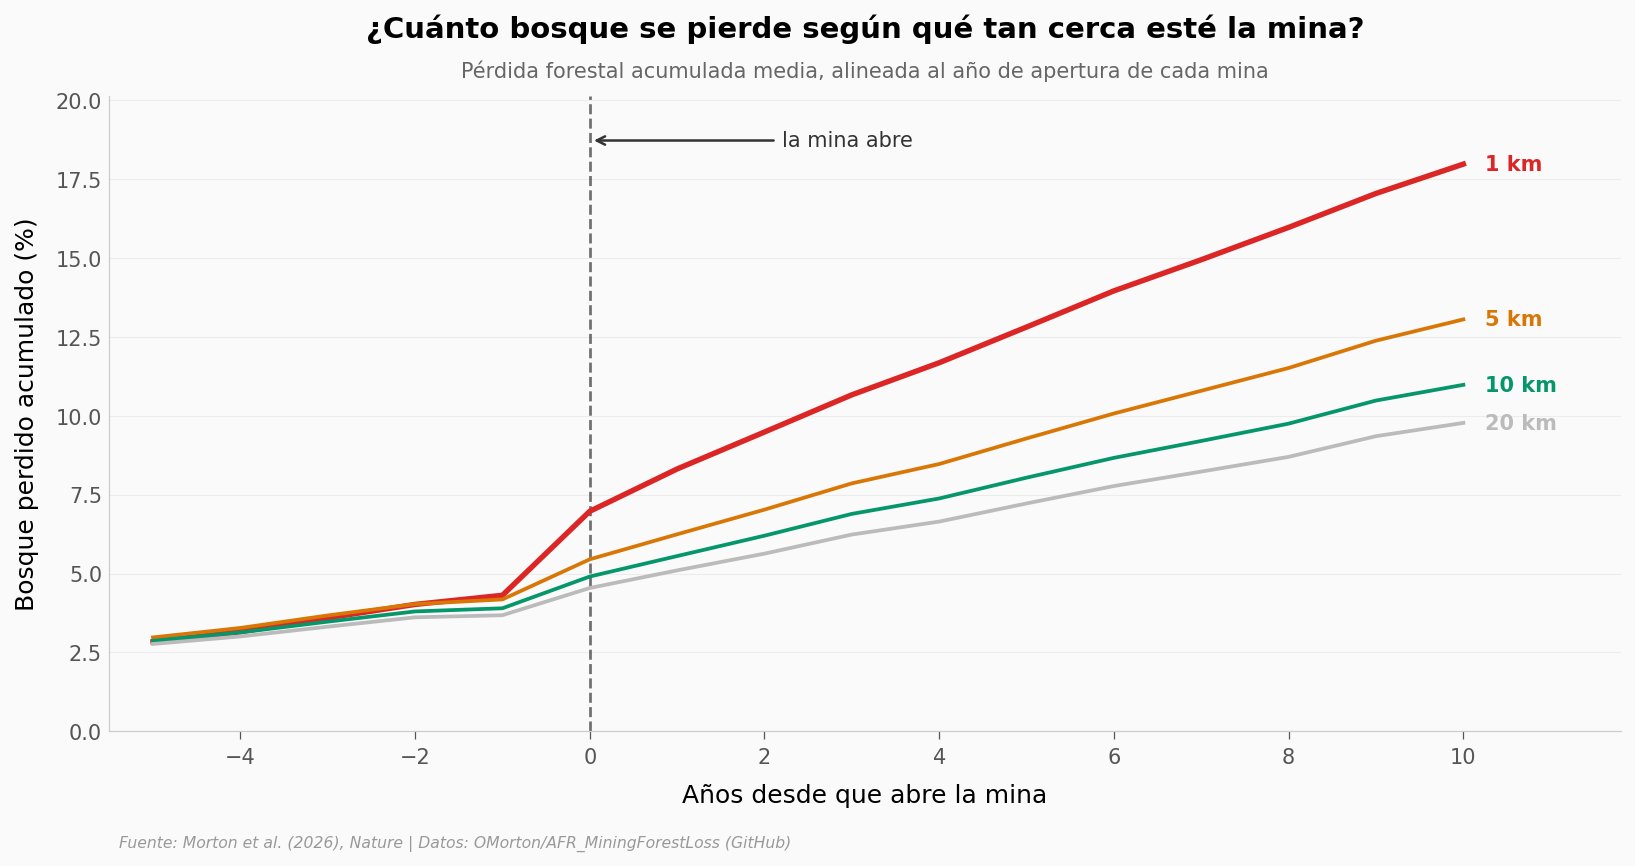

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

anillos = [('1km', COLOR_CERCA, '1 km'),
           ('5km', COLOR_MEDIO, '5 km'),
           ('10km', COLOR_LEJOS, '10 km'),
           ('20km', COLOR_FONDO, '20 km')]

for buf, color, etiqueta in anillos:
    sub = ev[ev.buffer == buf].sort_values('rel_year')
    lw = 2.6 if buf == '1km' else 1.8
    ax.plot(sub.rel_year, sub.mean_cum_loss_pct, color=color, lw=lw, zorder=5)
    ult = sub.iloc[-1]
    ax.text(ult.rel_year + 0.25, ult.mean_cum_loss_pct, etiqueta,
            color=color, fontweight='bold', fontsize=10, va='center')

# Marca del año en que abre la mina
ax.axvline(0, color='#333333', lw=1.3, ls='--', alpha=0.7, zorder=2)
ymax = ev.mean_cum_loss_pct.max() * 1.12
ax.set_ylim(0, ymax)
ax.annotate('la mina abre', xy=(0, ymax * 0.93), xytext=(2.2, ymax * 0.93),
            fontsize=10, color='#333333', va='center',
            arrowprops=dict(arrowstyle='->', color='#333333', lw=1.2))

ax.set_title('¿Cuánto bosque se pierde según qué tan cerca esté la mina?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Pérdida forestal acumulada media, alineada al año de apertura de cada mina',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Años desde que abre la mina')
ax.set_ylabel('Bosque perdido acumulado (%)')
ax.set_xlim(-5.5, 11.8)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/evento_estudio.png', dpi=200, bbox_inches='tight')
plt.show()

Antes de que la mina abra, los cuatro anillos van casi pegados: el bosque se pierde despacio y por igual. En el año cero la curva de **1 km** se despega del resto y ya no vuelve a alcanzarla — diez años después acumula cerca del **18%** de pérdida, mientras el anillo de 20 km se queda en torno al 10%.

El patrón es claro: cuanto más cerca de la mina, más bosque desaparece, y la distancia entre las curvas se abre justo cuando empieza la actividad. Eso es una **foto del gradiente espacial** — describe *dónde* cae el bosque. Para decir cuánto de eso **causa** la mina (y no algo que habría pasado igual) hace falta el siguiente paso.

## ¿Y cuánto es culpa de la mina?

El anillo de 20 km sirve de **fondo**: es lo que se pierde "de base" en la región. Si a cada anillo le restamos ese fondo, queda el exceso atribuible a tener la mina cerca. El paper hace esto con todo el aparato estadístico; nosotros lo hacemos a mano.

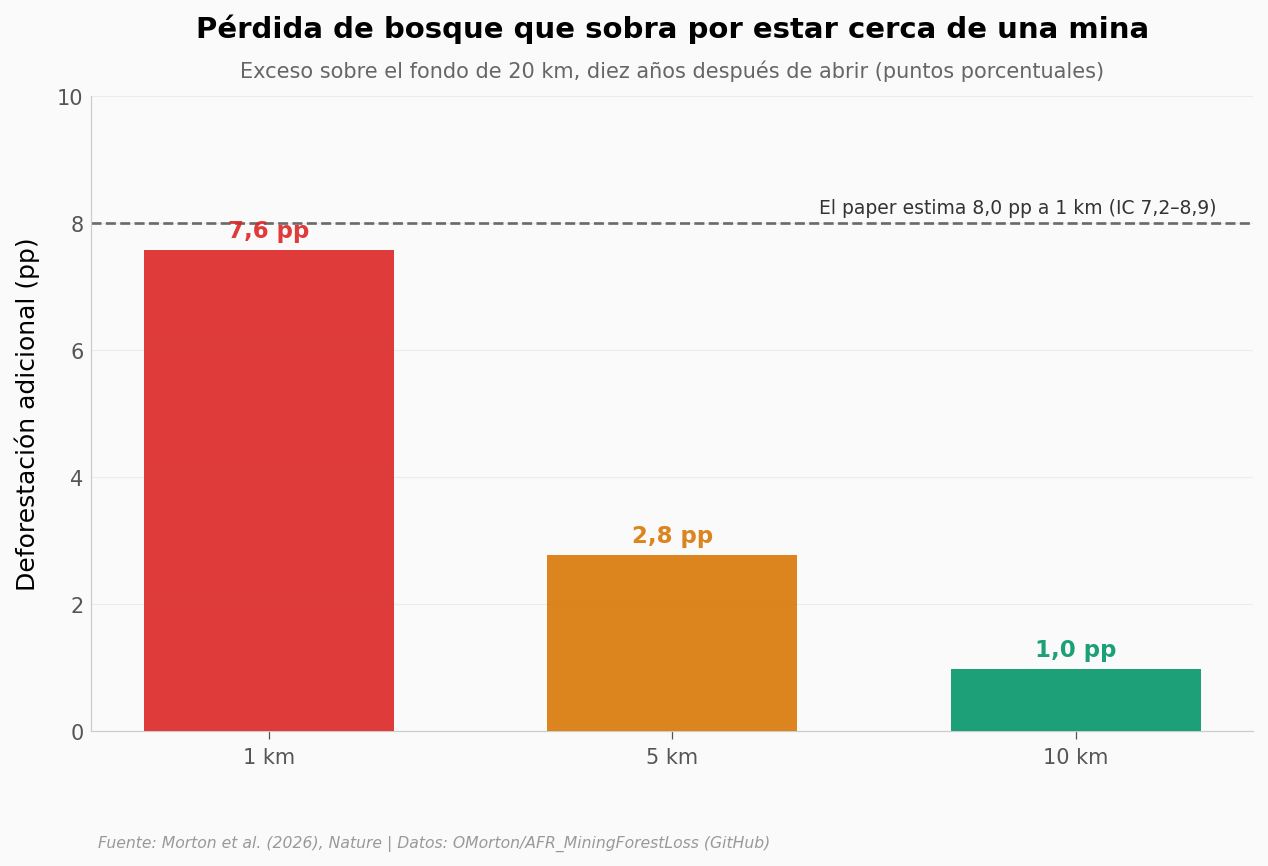

Nuestra reproducción cruda a 1 km: 7.57 pp
Titular del paper (DiD ajustado):  8.0 pp (IC 7,2–8,9)
Cae dentro del intervalo del paper — y por usar 20 km como fondo,
que ya tiene algo de exceso, lo nuestro es un límite INFERIOR.


In [3]:
d10 = dd[dd.rel_year == 10].copy()
orden = {'1km': 0, '5km': 1, '10km': 2}
d10 = d10.sort_values('ring', key=lambda s: s.map(orden))
etiquetas = ['1 km', '5 km', '10 km']
valores = d10.additional_pp.values
colores = [COLOR_CERCA, COLOR_MEDIO, COLOR_LEJOS]

fig, ax = plt.subplots(figsize=(10, 5.5))
barras = ax.bar(etiquetas, valores, color=colores, alpha=0.9, zorder=5, width=0.62)
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width()/2, v + 0.2, f'{v:.1f} pp'.replace('.', ','),
            ha='center', fontsize=11, fontweight='bold', color=b.get_facecolor())

# Referencia: el titular causal del paper (DiD ajustado)
ax.axhline(HEADLINE_PAPER_PP, color='#333333', lw=1.3, ls='--', alpha=0.7)
ax.text(2.35, HEADLINE_PAPER_PP + 0.15,
        f'El paper estima {HEADLINE_PAPER_PP:.0f}'.replace('.', ',') + ',0 pp a 1 km (IC 7,2–8,9)',
        fontsize=9, color='#333333', ha='right')

ax.set_title('Pérdida de bosque que sobra por estar cerca de una mina',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Exceso sobre el fondo de 20 km, diez años después de abrir (puntos porcentuales)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Deforestación adicional (pp)')
ax.set_ylim(0, max(valores.max(), HEADLINE_PAPER_PP) * 1.25)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/adicional_distancia.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Nuestra reproducción cruda a 1 km: {valores[0]:.2f} pp')
print(f'Titular del paper (DiD ajustado):  {HEADLINE_PAPER_PP:.1f} pp (IC 7,2–8,9)')
print('Cae dentro del intervalo del paper — y por usar 20 km como fondo,\n'
      'que ya tiene algo de exceso, lo nuestro es un límite INFERIOR.')

## No todos los minerales pesan igual

Una cosa es "una mina" y otra es **qué** saca. El paper separó el exceso a 1 km según el mineral principal. Aquí aparecen los que llevas encima: el **cobalto** y el **cobre** de baterías y electrónica.

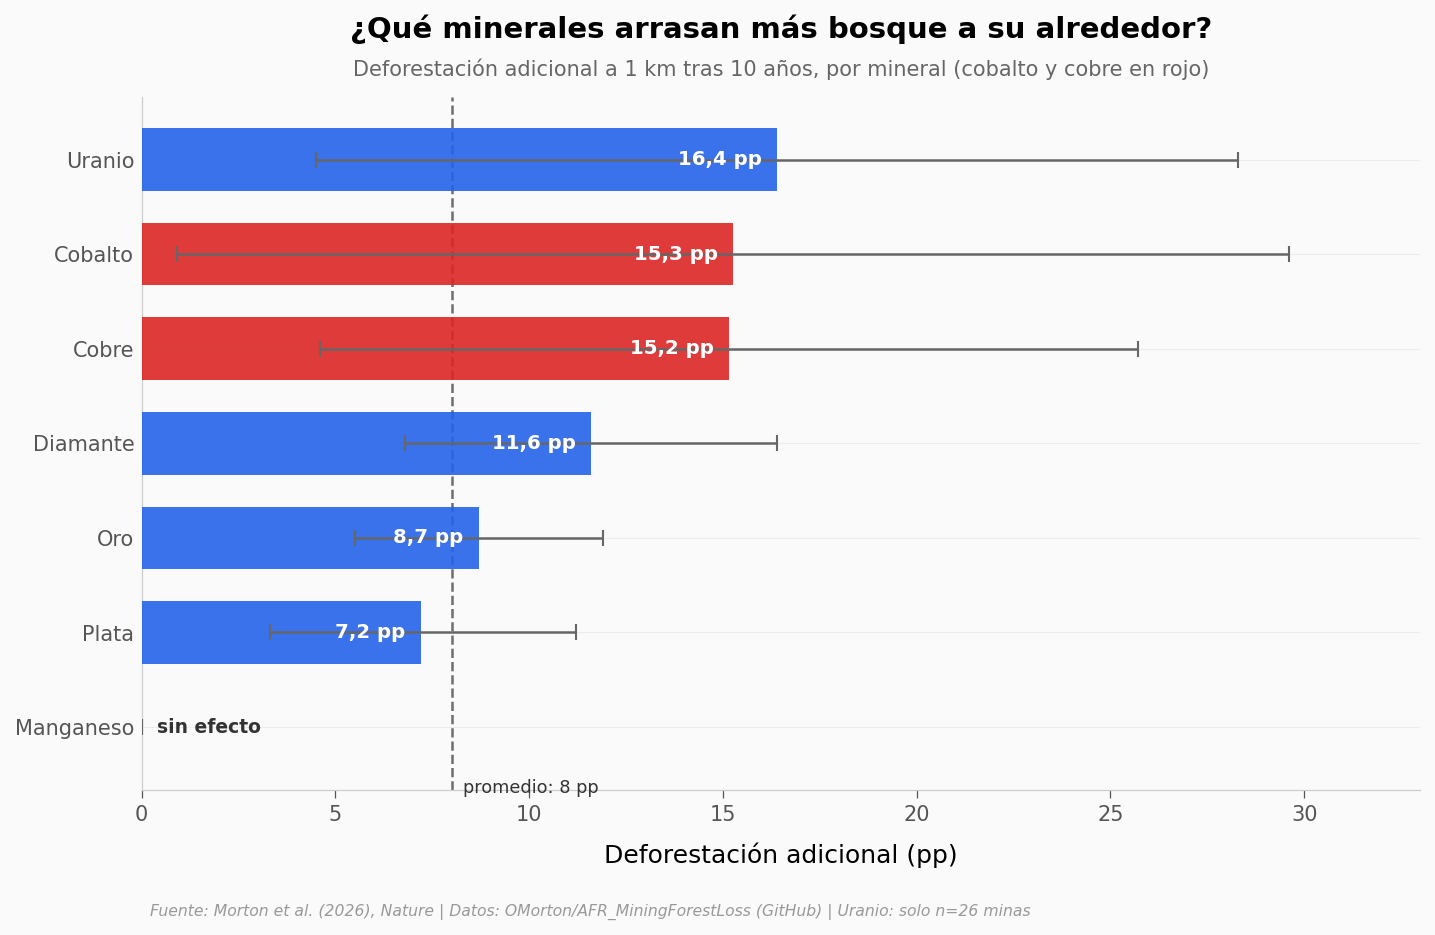

In [4]:
co_ord = co.sort_values('additional_pp_1km_10yr').reset_index(drop=True)
destacar = {'Cobalto', 'Cobre'}
colores = [COLOR_CERCA if m in destacar else COLOR_DATOS for m in co_ord.commodity]

fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(co_ord))
vals = co_ord.additional_pp_1km_10yr.values

# Barras de error solo donde hay IC
xerr_low = vals - co_ord.ci_low.values
xerr_high = co_ord.ci_high.values - vals
tiene_ci = ~np.isnan(co_ord.ci_low.values)
xerr = np.array([np.where(tiene_ci, xerr_low, 0),
                 np.where(tiene_ci, xerr_high, 0)])

ax.barh(y, vals, color=colores, alpha=0.9, zorder=5, height=0.66)
ax.errorbar(vals, y, xerr=xerr, fmt='none', ecolor='#666666',
            elinewidth=1.2, capsize=4, zorder=6)
ax.set_yticks(y)
ax.set_yticklabels(co_ord.commodity, fontsize=10)

for yi, v, m in zip(y, vals, co_ord.commodity):
    if v == 0:
        ax.text(0.4, yi, 'sin efecto', va='center', fontsize=9,
                color='#333333', fontweight='bold')
    else:
        txt = f'{v:.1f}'.replace('.', ',') + ' pp'
        ax.text(v - 0.4, yi, txt, va='center', ha='right', fontsize=9.5,
                color='white', fontweight='bold', zorder=10)

# Promedio del paper como referencia
ax.axvline(HEADLINE_PAPER_PP, color='#333333', lw=1.2, ls='--', alpha=0.7)
ax.text(HEADLINE_PAPER_PP + 0.3, -0.7, 'promedio: 8 pp',
        fontsize=8.5, color='#333333')

ax.set_title('¿Qué minerales arrasan más bosque a su alrededor?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Deforestación adicional a 1 km tras 10 años, por mineral (cobalto y cobre en rojo)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Deforestación adicional (pp)')
ax.set_xlim(0, 33)

fig.text(0.13, -0.03, FUENTE + ' | Uranio: solo n=26 minas',
         fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/por_mineral.png', dpi=200, bbox_inches='tight')
plt.show()

## El bosque que no se ve

La huella directa de todas las minas suma **187.070 hectáreas** de bosque denso. Suena mucho — pero es la parte visible. ¿Cuánto bosque cae *alrededor*, por los caminos, los cultivos y los pueblos que la mina arrastra?

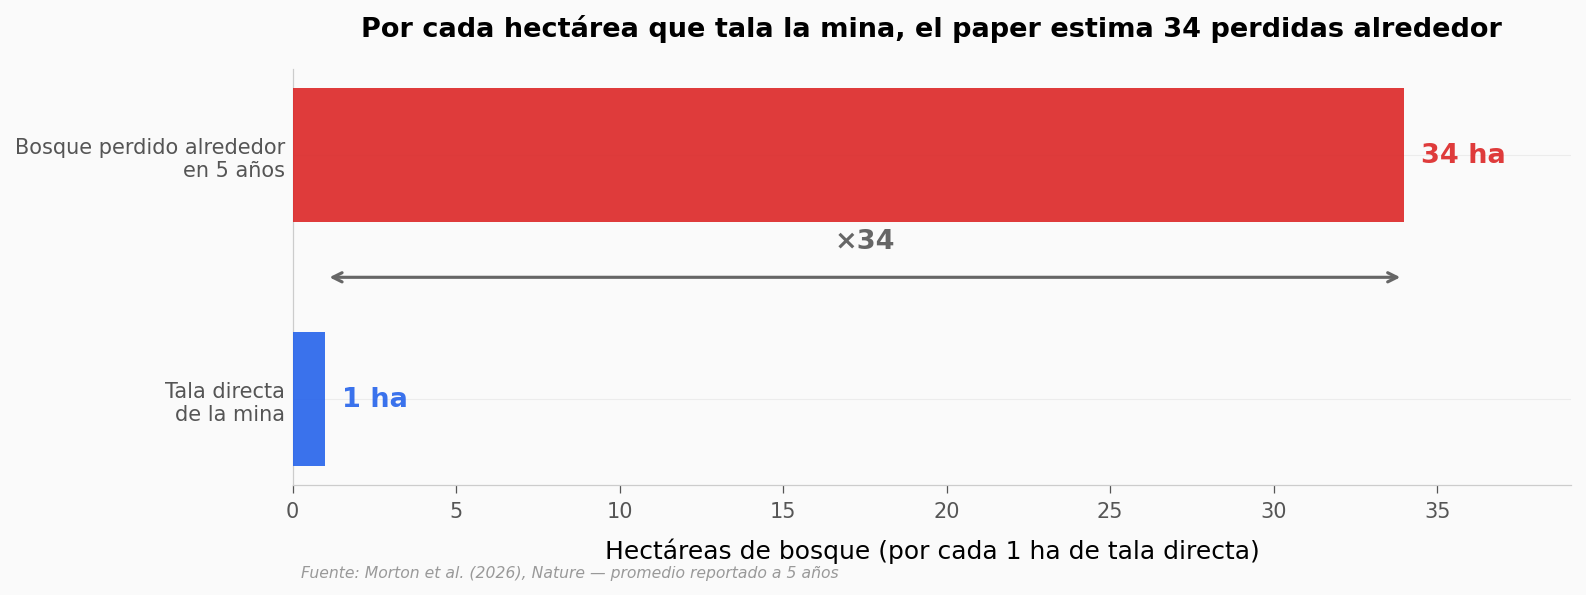

In [5]:
fig, ax = plt.subplots(figsize=(11, 3.6))

categorias = ['Tala directa\nde la mina', 'Bosque perdido alrededor\nen 5 años']
valores = [1, RATIO_OFFSITE]
colores = [COLOR_DATOS, COLOR_CERCA]
barras = ax.barh(categorias, valores, color=colores, alpha=0.9, height=0.55, zorder=5)

for b, v in zip(barras, valores):
    ax.text(v + 0.5, b.get_y() + b.get_height()/2, f'{v} ha',
            va='center', fontsize=13, fontweight='bold', color=b.get_facecolor())

# Flecha que mide la brecha
ax.annotate('', xy=(RATIO_OFFSITE, 0.5), xytext=(1, 0.5),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((RATIO_OFFSITE + 1) / 2, 0.62, f'×{RATIO_OFFSITE}',
        ha='center', fontsize=13, fontweight='bold', color='#666666')

ax.set_xlim(0, RATIO_OFFSITE * 1.15)
ax.set_xlabel('Hectáreas de bosque (por cada 1 ha de tala directa)')
ax.set_title('Por cada hectárea que tala la mina, el paper estima 34 perdidas alrededor',
             fontsize=13, fontweight='bold', pad=16)

fig.text(0.13, -0.06, 'Fuente: Morton et al. (2026), Nature — promedio reportado a 5 años',
         fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ratio_offsite.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Cerca de las minas se pierde más bosque (gradiente espacial) | ✅ | El anillo de 1 km se despega del de 20 km justo en el año de apertura; nuestra reproducción cruda lo muestra directo. |
| La mina añade ~8 pp de deforestación a 1 km | ✅ | Reproducción cruda: 7,57 pp, dentro del IC del paper (7,2–8,9). El 8,0 pp causal viene del DiD ajustado del paper, no de nuestras medias crudas. |
| Cobalto y cobre están entre los que más bosque arrasan | ✅ | 15,3 y 15,2 pp a 1 km, casi el doble del promedio (8 pp). |
| 34 ha alrededor por cada 1 ha de tala directa | ⚠️ | Cifra reportada por el paper (marco DiD), no recalculada aquí; la mostramos como dato del paper. |
| El uranio es el peor mineral | ⚠️ | Su punto es el más alto (16,4 pp) pero con solo n=26 minas y un IC enorme (4,5–28,3): mucha incertidumbre. |

> **Limitaciones:** el filtro de bosque *denso* del paper (`third.forest.clusters.csv`) no está en el repo público, así que usamos todos los clústeres con cobertura. Nuestras cifras son **medias crudas descriptivas**, no la diferencia-en-diferencias ajustada con covariables del paper. Usar el anillo de 20 km como fondo es conservador (ahí aún persiste ~1,1 pp de exceso), por lo que nuestro 7,57 pp es un **límite inferior** del efecto real.

## Ahora tú

1. **¿En qué año se separa de verdad la curva de 1 km?** Mira `ev` filtrando `buffer == '1km'` y compara `excess_vs_tm1` antes y después del año 0.
2. **¿Y si el fondo fuera 10 km en vez de 20 km?** En `dd`, ¿cuánto cambiaría el exceso adicional a 1 km? (pista: 10 km todavía tiene algo de efecto de la mina).
3. **¿Qué mineral tiene el intervalo más incierto?** Calcula el ancho del IC (`ci_high - ci_low`) en `co` y ordena.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué mineral tiene más incertidumbre? Ancho del intervalo de confianza.
co_ic = co.dropna(subset=['ci_low', 'ci_high']).copy()
co_ic['ancho_ic'] = co_ic.ci_high - co_ic.ci_low
print(co_ic[['commodity', 'additional_pp_1km_10yr', 'ci_low', 'ci_high', 'ancho_ic']]
      .sort_values('ancho_ic', ascending=False)
      .to_string(index=False))

print('\nEl uranio tiene el punto más alto, pero con un intervalo enorme')
print('(solo n=26 minas). Cobalto y cobre lo siguen — el paper los señala')
print('como los que más bosque arrasan — aunque sus intervalos también son')
print('anchos (el del cobalto baja casi hasta cero). Oro, plata y diamante')
print('se estiman con más precisión, pero con efectos menores.')

commodity  additional_pp_1km_10yr  ci_low  ci_high  ancho_ic
  Cobalto                   15.27     0.9     29.6      28.7
   Uranio                   16.40     4.5     28.3      23.8
    Cobre                   15.16     4.6     25.7      21.1
 Diamante                   11.60     6.8     16.4       9.6
    Plata                    7.20     3.3     11.2       7.9
      Oro                    8.70     5.5     11.9       6.4

El uranio tiene el punto más alto, pero con un intervalo enorme
(solo n=26 minas). Cobalto y cobre lo siguen — el paper los señala
como los que más bosque arrasan — aunque sus intervalos también son
anchos (el del cobalto baja casi hasta cero). Oro, plata y diamante
se estiman con más precisión, pero con efectos menores.


## Fuentes

**Paper**: [Mining triggers extensive additional deforestation in sub-Saharan Africa](https://doi.org/10.1038/s41586-026-10551-2)  
*Nature, 2026-06-03*

**Dataset canónico**: [OMorton/AFR_MiningForestLoss — processed forest-loss buffer panels + DiD code](https://github.com/OMorton/AFR_MiningForestLoss)  
*paneles de pérdida forestal procesados + código DiD*

**Referencias citadas**: [Post-deforestation land use dataset (ref 23, citado por el paper)](https://doi.org/10.5281/zenodo.11065705)

*12 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook reproducible de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-06-03-mineria-deforestacion-africa).*